<a href="https://colab.research.google.com/github/Subhajit14mandal/cat-dog-cnn-baseline/blob/main/cat_dog_cnn_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Libraries

In [ ]:
import tensorflow

In [ ]:
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

# Dataset Loading

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale = 1./255)

train = train_datagen.flow_from_directory('/content/drive/MyDrive/CNN/archive (2)/training_set/training_set',
                                                 target_size = (64, 64),
                                                 batch_size = 30,
                                                 class_mode = 'binary')
test = test_datagen.flow_from_directory('/content/drive/MyDrive/CNN/archive (2)/test_set/test_set',
                                            target_size = (64, 64),
                                            batch_size = 30,
                                            class_mode = 'binary')

Found 8008 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [ ]:
train.class_indices

{'cats': 0, 'dogs': 1}

# Check Imbalance

In [ ]:
import pandas as pd
import numpy as np

# Get the class indices from the training generator
class_indices = train.class_indices

# Get the labels (class indices) for each image in the training set
image_labels = train.labels

# Count the occurrences of each class index in the labels
class_counts = np.bincount(image_labels)

# Create a list of class names and their corresponding counts
# Ensure the order of class names matches the order of counts from np.bincount
class_names = list(class_indices.keys())
class_data = [(class_names[i], count) for i, count in enumerate(class_counts)]

# Create a pandas DataFrame for better visualization
class_counts_df = pd.DataFrame(class_data, columns=['Class', 'Count'])

# Display the DataFrame
display(class_counts_df)

,Class,Count
0,cats,4003
1,dogs,4005


In [ ]:

unique, counts = np.unique(train.labels, return_counts=True)
dict(zip(train.class_indices.keys(), counts))

{'cats': np.int64(4003), 'dogs': np.int64(4005)}

In [ ]:
unique

array([0, 1], dtype=int32)

In [ ]:
counts

array([4003, 4005])

Text(0.5, 1.0, 'Class Distribution')

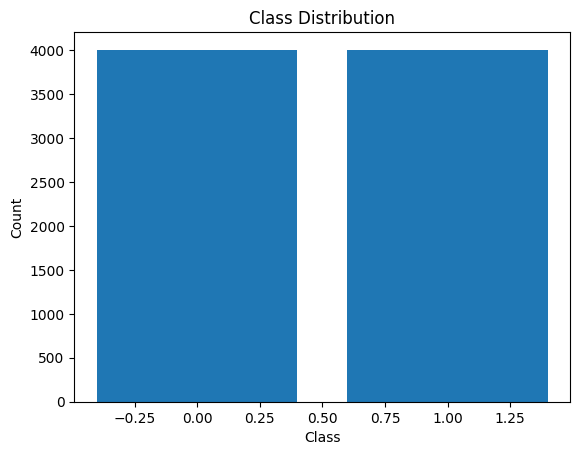

In [ ]:
plt.bar(unique, counts)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')

# CNN Model Architecture

In [ ]:
cnn=Sequential()

In [ ]:
cnn.add(Conv2D(32,(3,3),input_shape=(64,64,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Conv2D(32,(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.add(Dense(units=128,activation='relu'))
cnn.add(Dense(units=64,activation='relu'))
cnn.add(Dense(units=32,activation='relu'))
cnn.add(Dense(units=16,activation='relu'))
cnn.add(Dense(units=8,activation='relu'))
cnn.add(Dense(units=4,activation='relu'))
cnn.add(Dense(units=1,activation='sigmoid'))

# Training Configuration

In [ ]:
cnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

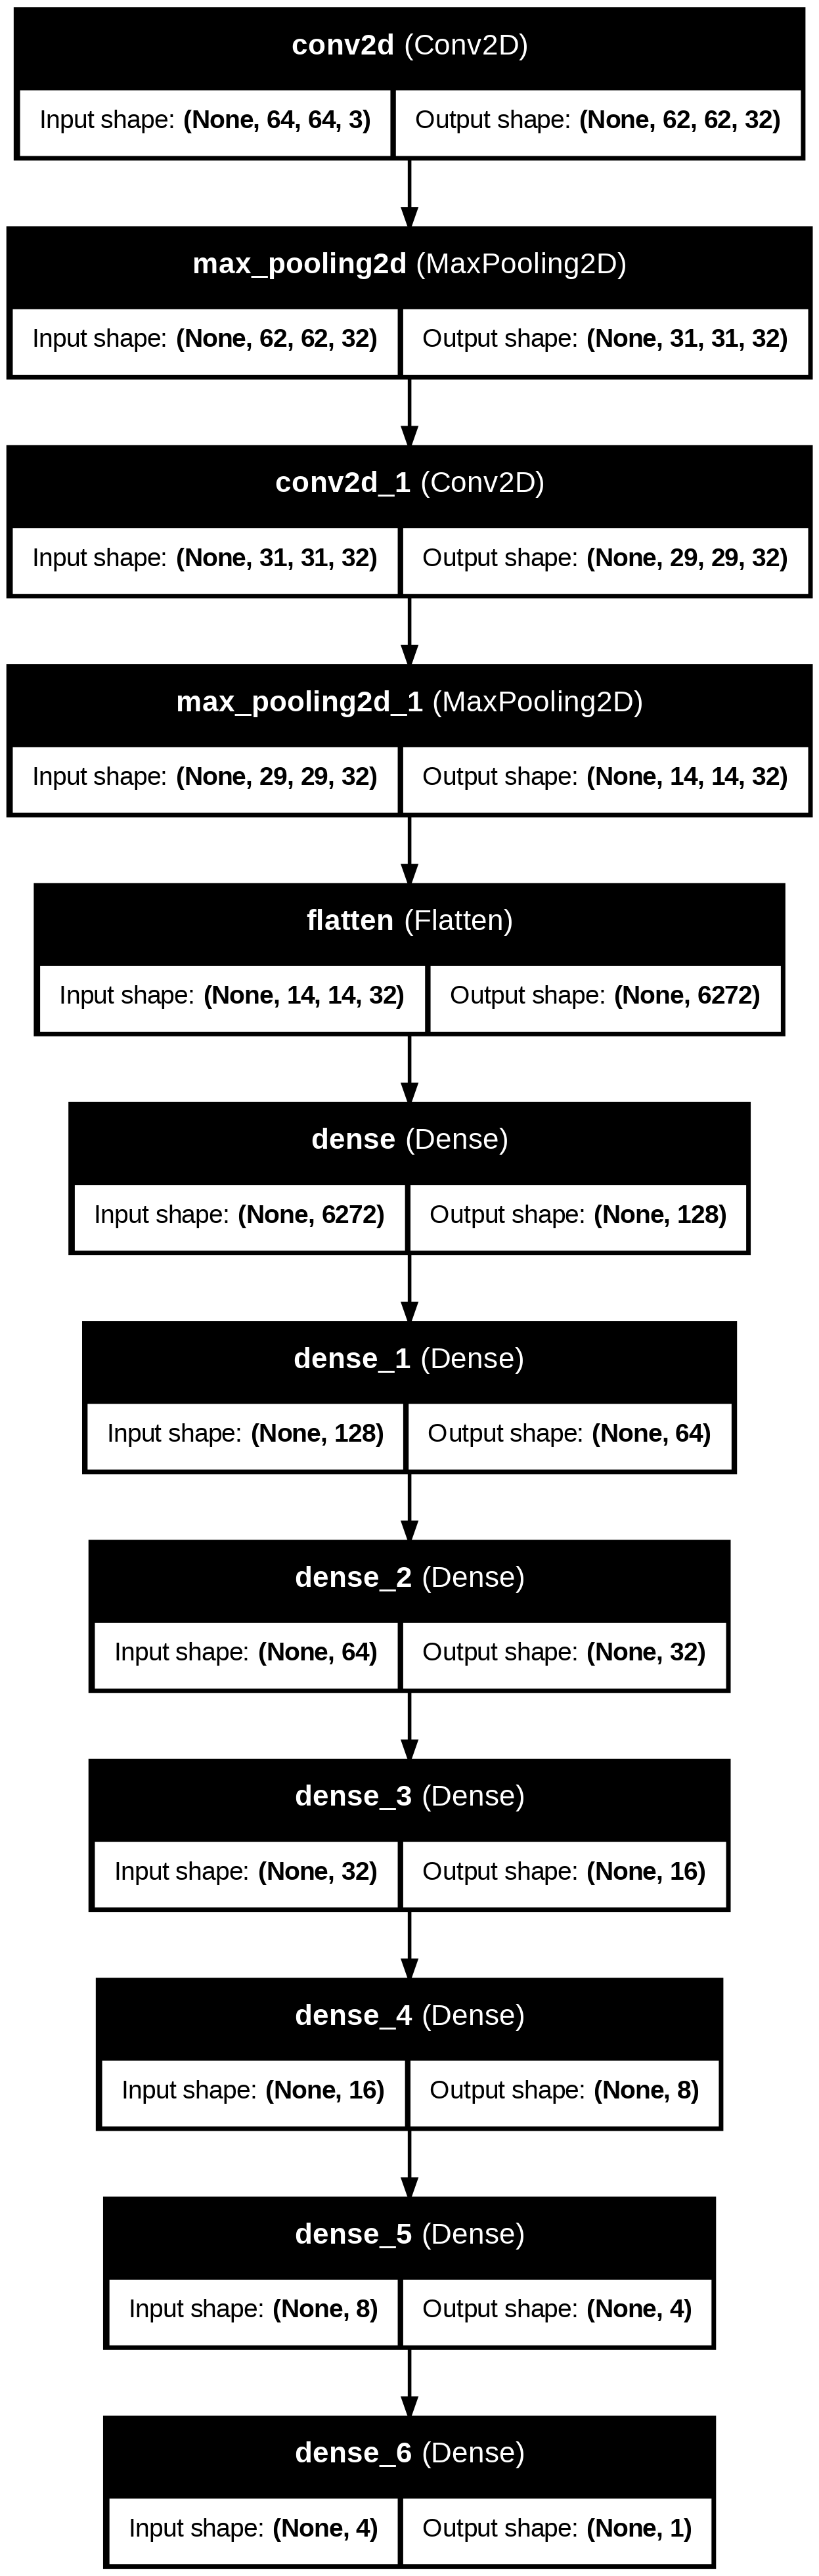

In [ ]:
from keras.utils import plot_model
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
from keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor='val_loss',
                         mode='min',
                         patience=8,
                         restore_best_weights=True,
                         verbose=1)

In [ ]:
from keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss',mode='max',
                                 factor=0.3, patience=4,
                                 verbose=1, min_lr=1e-6)
print("Learning rate scheduler 'ReduceLROnPlateau' defined.")

Learning rate scheduler 'ReduceLROnPlateau' defined.


In [ ]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,129 (3.14 MB)

 Trainable params: 824,129 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [ ]:
history=cnn.fit(train, epochs = 100, validation_data = test,
        callbacks=[lr_scheduler,early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 5035s 19s/step - accuracy: 0.4874 - loss: 0.6942 - val_accuracy: 0.5002 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 51s 191ms/step - accuracy: 0.5009 - loss: 0.6932 - val_accuracy: 0.4998 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 53s 197ms/step - accuracy: 0.4847 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 52s 195ms/step - accuracy: 0.5030 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 5/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5022 - loss: 0.6932
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
267/267 ━━━━━━━━━━━━━━━━━━━━ 52s 195ms/step - accuracy: 0.5022 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 6/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 53s 199ms/step - accuracy:

# Model Evaluation

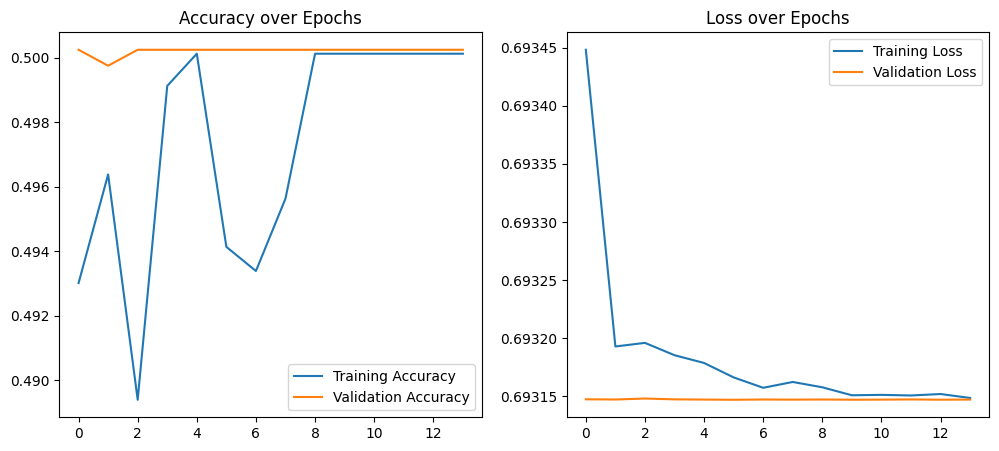

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()


In [ ]:
import shutil
import os

source_path = 'model_plot.png'
destination_path = '/content/drive/MyDrive/CNN/model_plot.png' # Assuming 'CNN' is the folder in your drive

# Ensure the destination directory exists
os.makedirs(os.path.dirname(destination_path), exist_ok=True)

# Copy the file
shutil.copy(source_path, destination_path)

print(f"'{source_path}' copied to '{destination_path}'")

In [ ]:
from keras.preprocessing import image
import numpy as np

img=image.load_img('/content/drive/MyDrive/CNN/labrador-retriever-dog-isolated-on-transparent-background-ai-generated-png.png', target_size=(64,64,3))
img=image.img_to_array(img)

img= np.expand_dims(img , axis=0)

In [ ]:
prediction=cnn.predict(img)
if prediction[0][0] < 0.5:
  print('Cat')
else:
  print('Dog')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
Dog


In [ ]:
from keras.preprocessing import image
import numpy as np

img=image.load_img('/content/drive/MyDrive/CNN/download.jpg', target_size=(64,64,3))
img=image.img_to_array(img)

img= np.expand_dims(img , axis=0)

In [ ]:
prediction=cnn.predict(img)
if prediction[0][0] < 0.5:
  print('Cat')
else:
  print('Dog')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Dog


68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step

Classification Report (Test Set):
               precision    recall  f1-score   support

        cats       0.00      0.00      0.00      1011
        dogs       0.50      1.00      0.67      1012

    accuracy                           0.50      2023
   macro avg       0.25      0.50      0.33      2023
weighted avg       0.25      0.50      0.33      2023



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


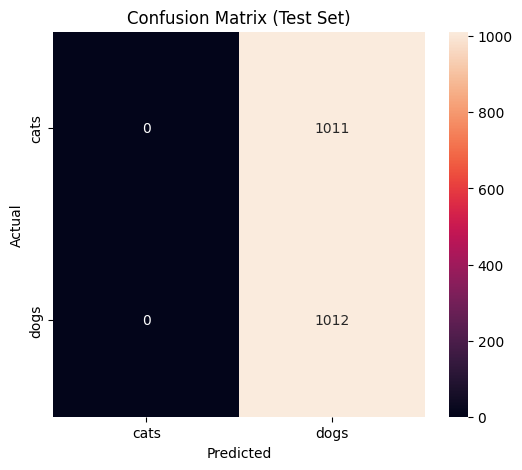

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Step 1: Predict on test set
y_pred_prob_test = cnn.predict(test)
y_pred_test=(y_pred_prob_test>0.5).astype(int)

# Step 2: True labels
y_true_test=test.classes

# Step 4: Classification Report
cr_test = classification_report(y_true_test, y_pred_test, target_names=list(test.class_indices.keys()))
print("\nClassification Report (Test Set):\n", cr_test)

# Step 5: Plot Confusion Matrix
cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', xticklabels=list(test.class_indices.keys()),
            yticklabels=list(test.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()